In [36]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import time
import torch
 
# ==========================================
# 1. HARDWARE CONFIGURATION
# ==========================================
print("Torch:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(f"🚀 Launching GPU Engine for 2000x1000 Grid on: {device}")

start = time.time()
 
fs = 100e6
fop = 6e9
c = 3e8
 
# 🎯 THE MATHEMATICAL SETUP: 10 samples * 1,000 rows per sample = 10,000 total rows
num_samples = 500
 
# Push receiver geometry arrays to GPU memory instantly
pos2 = torch.tensor([-300., 0., 0.], dtype=torch.float32, device=device)
pos3 = torch.tensor([300., 0., 0.], dtype=torch.float32, device=device)
pos4 = torch.tensor([-100., 300., 0.], dtype=torch.float32, device=device)
vel2 = torch.tensor([0., 0., 0.], dtype=torch.float32, device=device)
 
def fractional_delay_fft_gpu(s, delay_samples):
    N = len(s)
    k = torch.arange(N, dtype=torch.float32, device=device)
    phase_shift = torch.exp(-1j * 2 * np.pi * k * delay_samples / N)
    S = torch.fft.fft(s)
    return torch.fft.ifft(S * phase_shift)
 
def free_space_propagation_gpu(s, pos_tx, pos_rx, vel_tx, vel_rx, fs, fop):
    r_vec = pos_rx - pos_tx
    r = torch.linalg.norm(r_vec)
    if r < 1e-6: r = 1e-6
    tau = r / c
    delay_samples = tau * fs  
    v_radial = torch.dot(vel_tx - vel_rx, r_vec) / r
    fd = fop * v_radial / c
    y = fractional_delay_fft_gpu(s, delay_samples)
    t = torch.arange(len(y), dtype=torch.float32, device=device) / fs
    doppler_phase = 2 * np.pi * fd * t
    carrier_phase = 2 * np.pi * fop * tau
    y *= torch.exp(1j * (doppler_phase - carrier_phase))
    return y / r
 
# ==========================================
# 2. DATA GENERATION LOOP
# ==========================================
X1_list = []
X2_list = []
Ytx = np.zeros((num_samples, 4))
Yrx = np.zeros((num_samples, 8))
X_ts = []
Ds = []
 
np.random.seed(42)
torch.cuda.empty_cache() # Clear active memory locks before running
start_generation_clock = time.time()
 
print(f"⚡ Stacking {num_samples} samples vertically into a 2,000 x 1,000 array...")
for i in range(num_samples):
    x_pos = np.random.uniform(-350, 350)
    y_pos = np.random.uniform(100, 800)
    #pos1 = np.array([0., 100., 0.])
    vx, vy = 50.0, 10.0
    
    Ytx[i] = [x_pos, y_pos, vx, vy]
    Yrx[i] = [pos2[0].item(), pos2[1].item(), pos3[0].item(), pos3[1].item(), pos4[0].item(), pos4[1].item(), vel2[0].item(), vel2[1].item()]
    X_ts.append(1 / fs)
    Ds.append(50)
    
    pos1 = torch.tensor([x_pos, y_pos, 0.], dtype=torch.float32, device=device)
    vel1 = torch.tensor([vx, vy, 0.], dtype=torch.float32, device=device)
 
    # 📏 CONFIGURING EXACT SHAPES FOR 1000 COLUMNS AND 1000 ROWS PER SAMPLE
    N = 2_000_000   # 1,000,000 total signal points
    # Correct block setup
    block_size = 1000              
    num_blocks = N // block_size   # should be 10000 if data matches
    #print(num_blocks)
    
    # Generate complex random noise directly in graphics memory
    x1 = (torch.rand(N, device=device) - 0.5 + 1j * (torch.rand(N, device=device) - 0.5)) * 2.0
 
    y = free_space_propagation_gpu(x1, pos1, pos2, vel1, vel2, fs, fop)
    y3 = free_space_propagation_gpu(x1, pos1, pos3, vel1, vel2, fs, fop)
    y4 = free_space_propagation_gpu(x1, pos1, pos4, vel1, vel2, fs, fop)
 
    # Initialize cross-spectrum matrix storage layers inside active VRAM
    z3 = torch.zeros((num_blocks, block_size), dtype=torch.complex64, device=device)
    z5 = torch.zeros((num_blocks, block_size), dtype=torch.complex64, device=device)
 
    # 📥 YOUR ORIGINAL BLOCK LOOP STRUCTURE EXECUTING ON THE GPU CORES
    for k in range(num_blocks):
        idx = slice(k * block_size, (k + 1) * block_size)
 
        Z1 = torch.fft.fft(y[idx])
        Z2 = torch.fft.fft(y3[idx])
        Z4 = torch.fft.fft(y4[idx])
 
        z3[k, :] = Z1 * torch.conj(Z2)
        z5[k, :] = Z4 * torch.conj(Z2)
 
    # High-speed GPU 2D Fast-Fourier Transform mapping
    y5 = torch.abs(torch.fft.fft2(z3))
    y7 = torch.abs(torch.fft.fft2(z5))
 
    # Flips and maps array outputs back to host CPU for file aggregation
    y5 = torch.flip(y5, dims=[0]).cpu().numpy()
    y7 = torch.flip(y7, dims=[0]).cpu().numpy()
 
    X1_list.append(y5)
    X2_list.append(y7)
    
    # Free VRAM space after every iteration loop step to prevent cache bottlenecks
    torch.cuda.empty_cache()
 
# Vertical stacking combines your 10 samples into your exact final shape parameters
print(y5.shape)
print(y7.shape)
print("🥞 Merging structural layers into final dimensions...")
#X1 = np.vstack(X1_list)  # Final Shape: (10000, 1000)
#X2 = np.vstack(X2_list)  # Final Shape: (10000, 1000)
 
X1 = np.array(X1_list)   # ✅ shape: (N, 2000, 1000)
X2 = np.array(X2_list)

total_duration = time.time() - start_generation_clock
 
# ==========================================
# 3. SAVE SEPARATE MAT FILES
# ==========================================
datasetIp = {'x1': X1, 'x2': X2, 'Yip': Yrx, 'X_ts': np.array(X_ts), 'Ds': np.array(Ds)}
datasetOp = {'Y': Ytx}
 
print("💾 Writing high-resolution arrays to compressed .mat formats...")
sio.savemat('input_file500_50hDS.mat', datasetIp, do_compression=True)
sio.savemat('output_file500_50hDS.mat', datasetOp, do_compression=True)
 
print("\n" + "="*60)
print("🏁 GPU DATA PIPELINE COMPILATION COMPLETE")
print("="*60)
print(f"⏱️ Total Execution Duration : {total_duration:.2f} seconds")
print(f"📐 Input Matrix X1 Size     : {X1.shape} (Matches 2,000 x 1,000)")
print(f"📐 Input Matrix X2 Size     : {X2.shape} (Matches 2,000 x 1,000)")
print(f"📐 Supervised Label Size    : {Ytx.shape} (Matches 1 x 4)")
print("💾 Mat files archived successfully to local workspace directory.")
print("="*60)
print("Elapsed:", time.time()-start)
 

Torch: 2.8.0+gitb2fb688
GPU Available: True
cuda
🚀 Launching GPU Engine for 2000x1000 Grid on: cuda
⚡ Stacking 500 samples vertically into a 2,000 x 1,000 array...
(2000, 1000)
(2000, 1000)
🥞 Merging structural layers into final dimensions...
💾 Writing high-resolution arrays to compressed .mat formats...

🏁 GPU DATA PIPELINE COMPILATION COMPLETE
⏱️ Total Execution Duration : 103.43 seconds
📐 Input Matrix X1 Size     : (500, 2000, 1000) (Matches 2,000 x 1,000)
📐 Input Matrix X2 Size     : (500, 2000, 1000) (Matches 2,000 x 1,000)
📐 Supervised Label Size    : (500, 4) (Matches 1 x 4)
💾 Mat files archived successfully to local workspace directory.
Elapsed: 484.55483770370483


14
21
Peak magnitude: 1416.7487


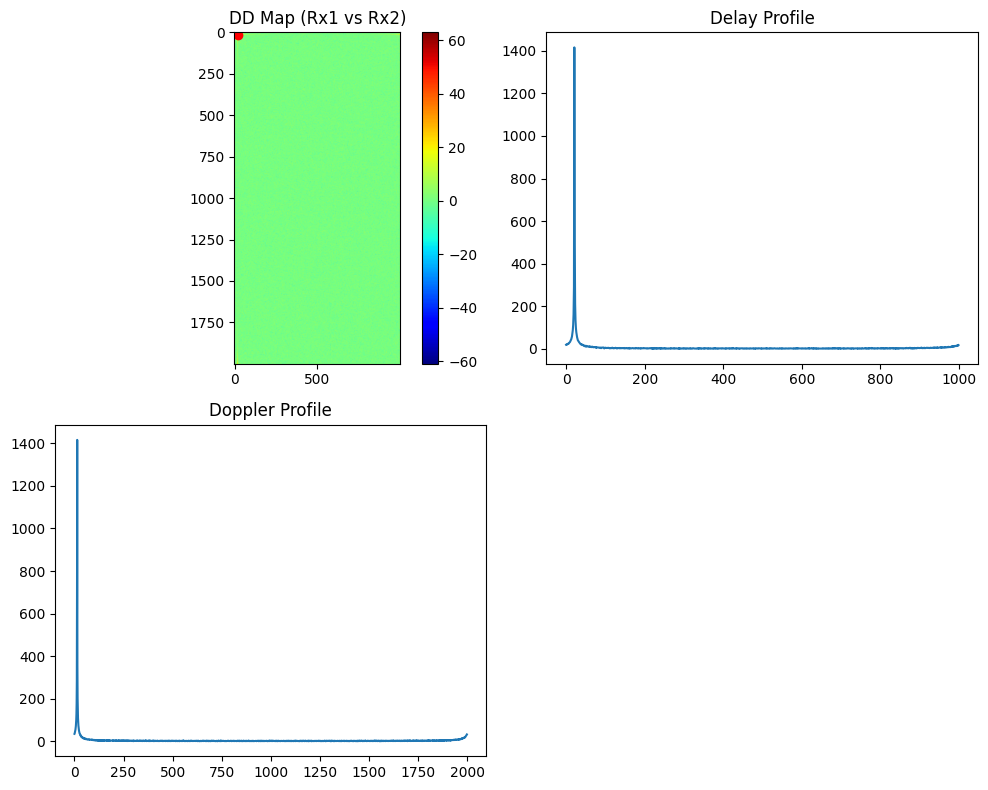

In [35]:
# ================= VISUALIZATION Part2 =================
# ===== FIRST MAP =====
y5_sample = X1[0]

#print(y5_sample[1:20,1:20])
row1, col1 = np.unravel_index(np.argmax(y5_sample), y5_sample.shape)

print(row1)
print(col1)

print("Peak magnitude:", peak_value)

plt.figure(figsize=(10,8))
 
plt.subplot(2,2,1)
plt.imshow(20*np.log10(y5_sample + 1e-6), cmap='jet')
plt.colorbar()
plt.scatter(col1, row1, color='red')
plt.title("DD Map (Rx1 vs Rx2)")
 
plt.subplot(2,2,2)
plt.plot(np.abs(y5_sample[row1, :]))
plt.title("Delay Profile")
 
plt.subplot(2,2,3)
plt.plot(np.abs(y5_sample[:, col1]))
plt.title("Doppler Profile")
 
'''
from mpl_toolkits.mplot3d import Axes3D
ax = plt.subplot(2,2,4, projection='3d')
Xg, Yg = np.meshgrid(np.arange(1000), np.arange(1000))
ax.plot_surface(Xg, Yg, y5_sample, cmap='jet')
plt.title("3D View")
'''
 
plt.tight_layout()
plt.show()


11
31
Peak magnitude: 1416.7487


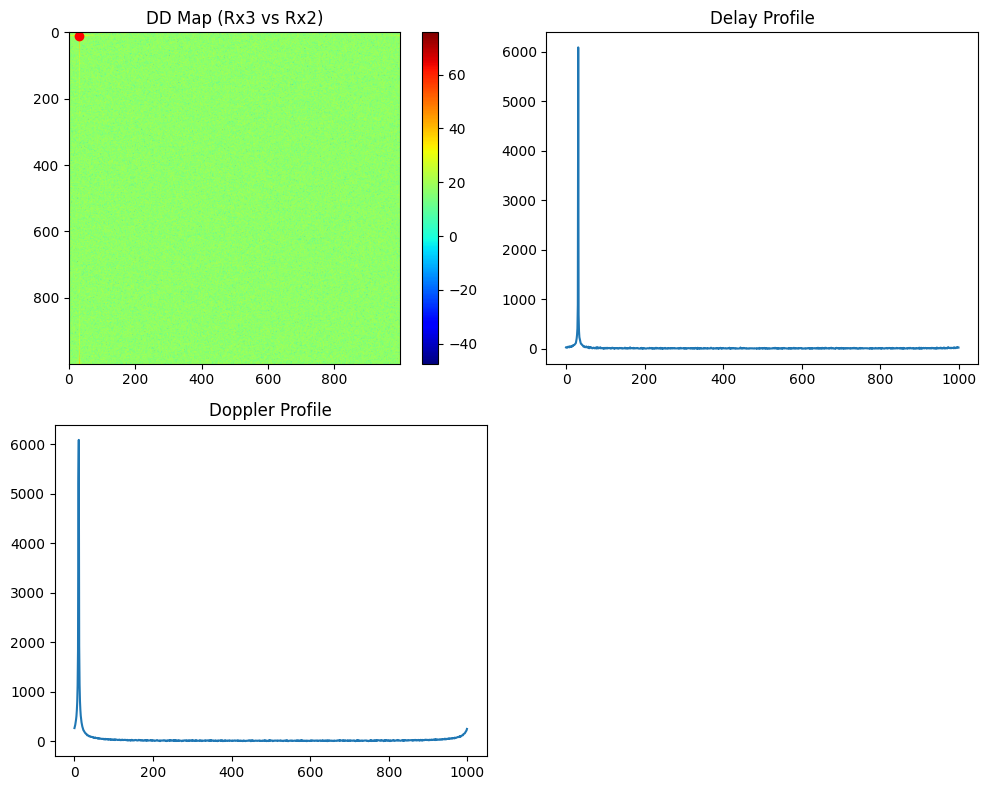

In [30]:
# ================= VISUALIZATION Part3 =================
# ===== SECOND MAP =====
y7_sample = X2
row2, col2 = np.unravel_index(np.argmax(y7_sample), y7_sample.shape)
print(row2)
print(col2)

print("Peak magnitude:", peak_value)

 
plt.figure(figsize=(10,8))
 
plt.subplot(2,2,1)
plt.imshow(20*np.log10(y7_sample + 1e-6), cmap='jet')
plt.colorbar()
plt.scatter(col2, row2, color='red')
plt.title("DD Map (Rx3 vs Rx2)")
 
plt.subplot(2,2,2)
plt.plot(np.abs(y7_sample[row2, :]))
plt.title("Delay Profile")
 
plt.subplot(2,2,3)
plt.plot(np.abs(y7_sample[:, col2]))
plt.title("Doppler Profile")


'''
ax = plt.subplot(2,2,4, projection='3d')
ax.plot_surface(Xg, Yg, y7_sample, cmap='jet')
plt.title("3D View")
'''
 
plt.tight_layout()
plt.show()